# **Predicting the Nature of Breast Mass Tissue using Machine Learning by Emiliano Pedraza, Physics Engineer**

In this Notebook, information from the UCI ML Breast Cancer Wisconsin (Diagnostic) dataset is accessed and processed with the objective of predicting the nature of breast mass tissue; a target field describes the benign or malignant nature of breast mass tissue cells, which are obtained via a fine needle aspiration biopsy. A 0 value represents malignant tissue (cancerous) while a 1 represents benign tissue (non-cancerous).

After using Scikit-Learn and Machine Learning processes to construct a prediction model, the results are graphed to better visualize the accuracy of the predictions.

Finally, MLflow is used to track multiple combinations and iterations of specific parameter tunings that influence the results of the predictions.

LIBRARIES

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import classification_report
import mlflow
import mlflow.sklearn

GETTING THE DATASET

In [ ]:
raw_bundle = load_breast_cancer()
cancer_df = pd.DataFrame(data=raw_bundle.data, columns=raw_bundle.feature_names)
cancer_df['target'] = raw_bundle.target

In [4]:
# Variables to tune
corr_threshold=0.70
testing_size=0.3
scaling_method=StandardScaler()
alpha_value=0.1

INITIAL EXPLORATION OF THE DATA

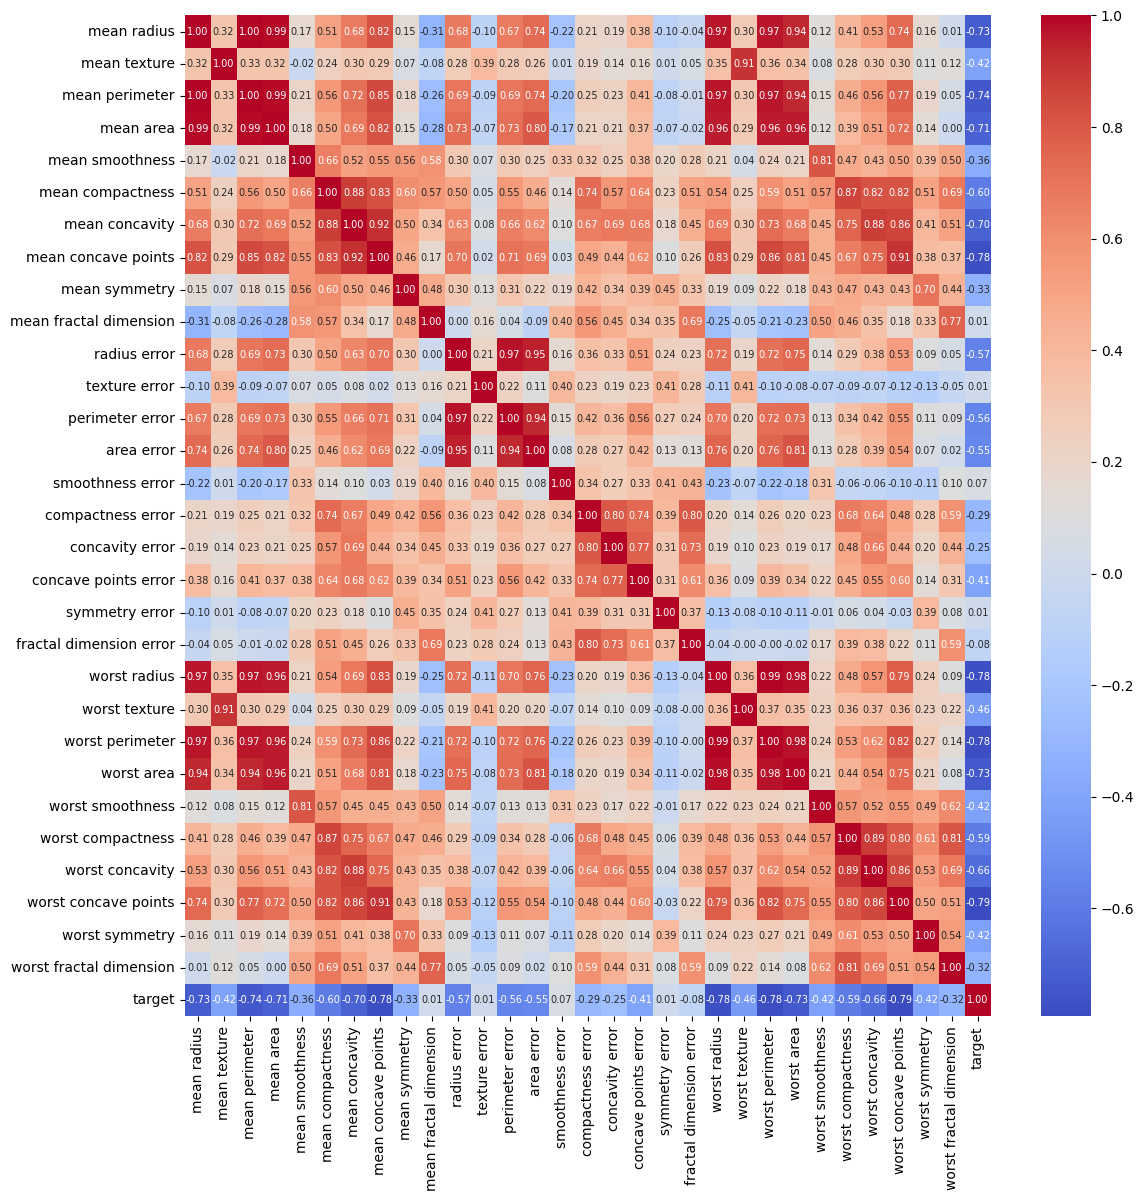

In [5]:
corr_matrix = cancer_df.corr(numeric_only=True)
plt.figure(figsize=(13, 13))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 7})
plt.show()

SELECTION OF RELEVANT FIELDS TO PREDICT THE NATURE OF THE BREAST TISSUE

In [6]:
relevant_fields=corr_matrix[corr_matrix.abs()["target"]>corr_threshold].index.tolist()
relevant_fields.remove("target")

In [7]:
print(relevant_fields)

['mean radius', 'mean perimeter', 'mean area', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concave points']


In [8]:
cancer_df[relevant_fields].head()

,mean radius,mean perimeter,mean area,mean concave points,worst radius,worst perimeter,worst area,worst concave points
0,17.99,122.80,1001.0,0.14710,25.38,184.60,2019.0,0.2654
1,20.57,132.90,1326.0,0.07017,24.99,158.80,1956.0,0.1860
2,19.69,130.00,1203.0,0.12790,23.57,152.50,1709.0,0.2430
3,11.42,77.58,386.1,0.10520,14.91,98.87,567.7,0.2575
4,20.29,135.10,1297.0,0.10430,22.54,152.20,1575.0,0.1625


SPLITTING

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(cancer_df[relevant_fields], cancer_df["target"], test_size=testing_size, random_state=42)

PIPELINE AND CROSS-VALIDATION

In [ ]:
#Pipeline
pipeline = Pipeline([
    ("scaler", scaling_method),
    ("regressor", Ridge(alpha=alpha_value))])

#Cross-Validation
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')

print(f"All 5 CV R² Scores: {cv_scores}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f}\n")

All 5 CV R² Scores: [0.69825352 0.63307265 0.75933479 0.68898688 0.74398697]
Mean CV R² Score: 0.7047



FITTING AND PREDICTION

In [12]:
#Fitting
pipeline.fit(X_train, y_train)

#Prediction
predictions = pipeline.predict(X_test)
y_predictions= [1 if val >= 0.5 else 0 for val in predictions]

mae = mean_absolute_error(y_test, y_predictions)
r2 = r2_score(y_test, y_predictions)

print(f"Final Test MAE: {mae:.4f}")
print(f"Final Test R² Score: {r2:.6f}")

Final Test MAE: 0.0468
Final Test R² Score: 0.798942


GRAPHS

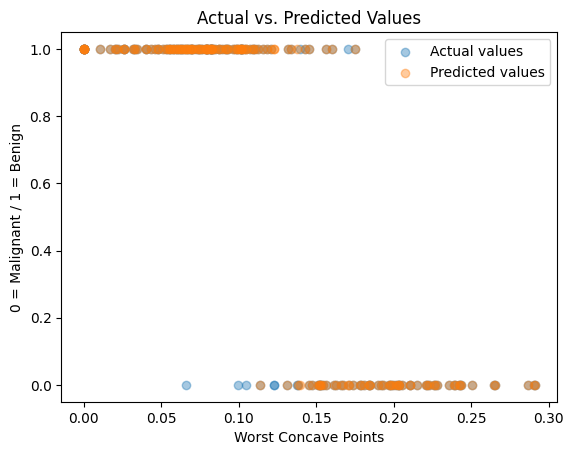

In [14]:
plt.scatter(X_test["worst concave points"], y_test, alpha= 0.4, label="Actual values")
plt.scatter(X_test["worst concave points"], y_predictions, alpha=0.4, label="Predicted values")
plt.xlabel("Worst Concave Points")
plt.ylabel("0 = Malignant / 1 = Benign")
plt.title("Actual vs. Predicted Values")
plt.legend()
plt.show()

In [15]:
class_report=classification_report(y_test, y_predictions, target_names=["Malignant", "Benign"], output_dict= True)
report=pd.DataFrame(class_report)
report["Index"]=report.index

In [16]:
report

,Malignant,Benign,accuracy,macro avg,weighted avg,Index
precision,0.966102,0.946429,0.953216,0.956265,0.953677,precision
recall,0.904762,0.981481,0.953216,0.943122,0.953216,recall
f1-score,0.934426,0.963636,0.953216,0.949031,0.952875,f1-score
support,63.000000,108.000000,0.953216,171.000000,171.000000,support


In [17]:
report=report[report["Index"]!="support"]

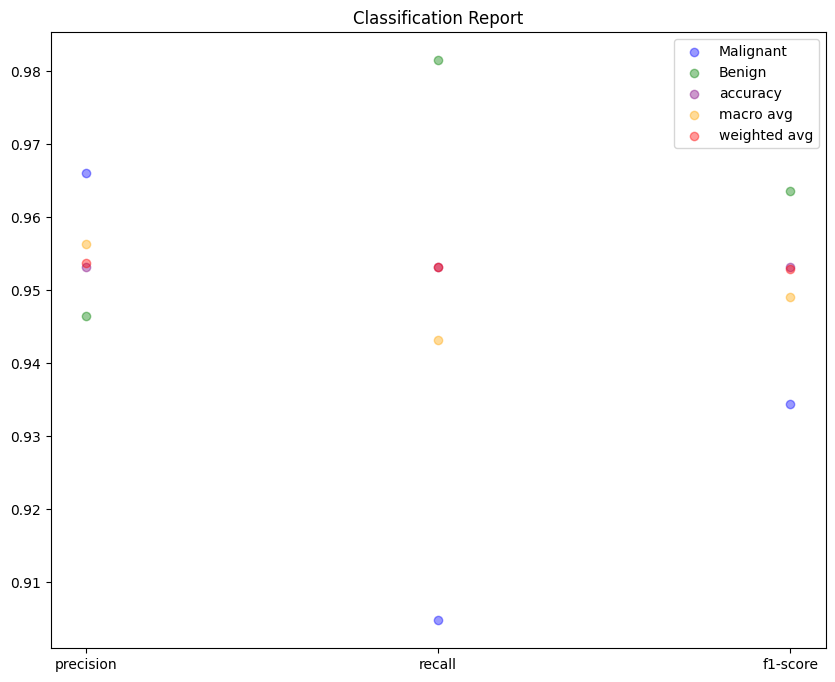

In [18]:
plt.figure(figsize=(10, 8))
plt.title("Classification Report")
plt.scatter(report["Index"], report["Malignant"], color="blue", alpha=0.4, label="Malignant")
plt.scatter(report["Index"], report["Benign"], color="green", alpha=0.4, label="Benign")
plt.scatter(report["Index"], report["accuracy"], color="purple", alpha=0.4, label="accuracy")
plt.scatter(report["Index"], report["macro avg"], color="orange", alpha=0.4, label="macro avg")
plt.scatter(report["Index"], report["weighted avg"], color="red", alpha=0.4, label="weighted avg")
plt.legend()
plt.show()

MLFLOW

In [19]:
# MlFlow
# install mlflow 

In [20]:
mlflow.set_experiment("Breast_Cancer_Regression_Experiment_New")

<Experiment: artifact_location='/workspaces/PersonalEPL/mlruns/4', creation_time=1781752659229, experiment_id='4', last_update_time=1781752659229, lifecycle_stage='active', name='Breast_Cancer_Regression_Experiment_New', tags={}, trace_location=None, workspace='default'>

CHANGING PARAMETERS

In [21]:
threshold_options = [0.70, 0.75, 0.80]
test_size_options = [0.2, 0.3]
scaling_options = [StandardScaler(), MinMaxScaler(), RobustScaler()]
alpha_options = [0.01, 0.1, 1.0, 10.0]

LOOPING AND LOGGING ON MLFLOW

In [22]:
for threshold in threshold_options:
    for test_size in test_size_options:
        for scaler in scaling_options:
            for alpha in alpha_options:
                
                run_name = f"Thresh_{threshold}_Size_{test_size}_{scaler.__class__.__name__}_Alpha_{alpha}"
                
                with mlflow.start_run(run_name=run_name):
                    
                    mlflow.log_param("corr_threshold", threshold)
                    mlflow.log_param("testing_size", test_size)
                    mlflow.log_param("scaling_method", scaler.__class__.__name__)
                    mlflow.log_param("alpha_value", alpha)
                    
                    #Pipeline, fitting and predictions
                    pipeline = Pipeline([('scaler', scaler),('regressor', Ridge(alpha=alpha))])
                    
                    pipeline.fit(X_train, y_train)
                    predictions = pipeline.predict(X_test)
                    y_predictions= [1 if val >= 0.5 else 0 for val in predictions]

                    
                    #Scores
                    r2 = r2_score(y_test, y_predictions)
                    mae = mean_absolute_error(y_test, y_predictions)
                    
                    #Logging metric
                    mlflow.log_metric("test_r2", r2)
                    mlflow.log_metric("test_mae", mae)

The following are the resulting metrics from MlFlow:
- Metric     |     Value
- test_r2     0.798941798941799
- test_mae    0.04678362573099415

with their respective optimal parameters:
- Parameter    |   Value
- corr_threshold  0.8
- testing_size    0.3
- scaling_method  RobustScaler
- alpha_value     1.0